In [12]:
# Reconnect to database — run this after rebuilding the database
conn.close()
conn = sqlite3.connect(DB_PATH)
print("✅ Reconnected to database")

# Verify
test = pd.read_sql_query("SELECT season, COUNT(*) as records FROM player_game_stats GROUP BY season", conn)
print(test)

✅ Reconnected to database
    season  records
0  2024-25      368
1  2025-26      301


In [4]:
import sys
import os
sys.path.append('Users/sethgannon/Projects/big-blue-nation-ai-analyst/src')

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to database
DB_PATH = '/Users/sethgannon/Projects/big-blue-nation-ai-analyst/data/processed/kentucky_basketball.db'
conn = sqlite3.connect(DB_PATH)

# Load player game stats
df = pd.read_sql_query("""
    SELECT * FROM player_game_stats
    ORDER BY game_date, player_name
""", conn)

print(f"Total records: {len(df)}")
print(f"Players: {df['player_name'].nunique()}")
print(f"Games: {df['game_id'].nunique()}")
df.head()

Total records: 301
Players: 14
Games: 30


,id,game_id,game_date,season,player_id,player_name,jersey,position,opponent,home_away,...,fg_made,fg_att,fg_pct,three_made,three_att,three_pct,ft_made,ft_att,ft_pct,updated_at
0,6,401826746,2025-11-05,2025-26,5281347,Andrija Jelavic,4,F,Nicholls Colonels,home,...,3,8,0.375,0,3,0.000,0,0,0.0,2026-03-05T20:22:21.586227
1,3,401826746,2025-11-05,2025-26,4711306,Brandon Garrison,10,F,Nicholls Colonels,home,...,4,6,0.667,0,1,0.000,0,0,0.0,2026-03-05T20:22:21.586227
2,4,401826746,2025-11-05,2025-26,5238207,Collin Chandler,5,G,Nicholls Colonels,home,...,5,8,0.625,4,7,0.571,1,2,0.5,2026-03-05T20:22:21.586227
3,9,401826746,2025-11-05,2025-26,5105527,Denzel Aberdeen,1,G,Nicholls Colonels,home,...,4,9,0.444,1,5,0.200,1,1,1.0,2026-03-05T20:22:21.586227
4,11,401826746,2025-11-05,2025-26,5095153,Jasper Johnson,2,G,Nicholls Colonels,home,...,3,7,0.429,1,4,0.250,4,5,0.8,2026-03-05T20:22:21.586227


In [5]:
# Look at the data more cleanly
print("=== COLUMNS ===")
print(df.columns.tolist())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== PLAYERS IN DATASET ===")
print(df['player_name'].value_counts())

=== COLUMNS ===
['id', 'game_id', 'game_date', 'season', 'player_id', 'player_name', 'jersey', 'position', 'opponent', 'home_away', 'starter', 'minutes', 'points', 'rebounds', 'assists', 'turnovers', 'steals', 'blocks', 'off_rebounds', 'def_rebounds', 'fouls', 'fg_made', 'fg_att', 'fg_pct', 'three_made', 'three_att', 'three_pct', 'ft_made', 'ft_att', 'ft_pct', 'updated_at']

=== DATA TYPES ===
id                int64
game_id             str
game_date           str
season              str
player_id           str
player_name         str
jersey              str
position            str
opponent            str
home_away           str
starter           int64
minutes           int64
points            int64
rebounds          int64
assists           int64
turnovers         int64
steals            int64
blocks            int64
off_rebounds      int64
def_rebounds      int64
fouls             int64
fg_made           int64
fg_att            int64
fg_pct          float64
three_made        int64
thr

In [6]:
# Convert date to datetime
df['game_date'] = pd.to_datetime(df['game_date'])

# Sort by player and date — critical for rolling averages
df = df.sort_values(['player_name', 'game_date']).reset_index(drop=True)

# === FEATURE ENGINEERING ===

# 1. Rolling averages (last 3 and last 5 games per player)
stats_to_roll = ['points', 'rebounds', 'assists', 'minutes', 
                 'fg_pct', 'three_pct', 'turnovers', 'steals']

for stat in stats_to_roll:
    df[f'{stat}_roll3'] = df.groupby('player_name')[stat].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
    df[f'{stat}_roll5'] = df.groupby('player_name')[stat].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )

# 2. Season averages up to that point (no data leakage)
for stat in stats_to_roll:
    df[f'{stat}_season_avg'] = df.groupby('player_name')[stat].transform(
        lambda x: x.shift(1).expanding().mean()
    )

# 3. Home/away flag
df['is_home'] = (df['home_away'] == 'home').astype(int)

# 4. Game number (how far into the season)
df['game_number'] = df.groupby('player_name').cumcount() + 1

# 5. Minutes trend (are they getting more or less playing time?)
df['minutes_trend'] = df['minutes_roll3'] - df['minutes_roll5']

# 6. Scoring trend
df['points_trend'] = df['points_roll3'] - df['points_roll5']

print("Features added successfully!")
print(f"\nNew columns added: {[c for c in df.columns if any(x in c for x in ['roll', 'avg', 'trend', 'is_home', 'game_number'])]}")
print(f"\nTotal features: {len(df.columns)}")
df[['player_name', 'game_date', 'points', 'points_roll3', 'points_roll5', 'points_season_avg']].head(10)

Features added successfully!

New columns added: ['points_roll3', 'points_roll5', 'rebounds_roll3', 'rebounds_roll5', 'assists_roll3', 'assists_roll5', 'minutes_roll3', 'minutes_roll5', 'fg_pct_roll3', 'fg_pct_roll5', 'three_pct_roll3', 'three_pct_roll5', 'turnovers_roll3', 'turnovers_roll5', 'steals_roll3', 'steals_roll5', 'points_season_avg', 'rebounds_season_avg', 'assists_season_avg', 'minutes_season_avg', 'fg_pct_season_avg', 'three_pct_season_avg', 'turnovers_season_avg', 'steals_season_avg', 'is_home', 'game_number', 'minutes_trend', 'points_trend']

Total features: 59


,player_name,game_date,points,points_roll3,points_roll5,points_season_avg
0,Andrija Jelavic,2025-11-05,6,NaN,NaN,NaN
1,Andrija Jelavic,2025-11-08,7,6.000000,6.000000,6.000000
2,Andrija Jelavic,2025-11-12,6,6.500000,6.500000,6.500000
3,Andrija Jelavic,2025-11-15,11,6.333333,6.333333,6.333333
4,Andrija Jelavic,2025-11-18,0,8.000000,7.500000,7.500000
5,Andrija Jelavic,2025-11-22,9,5.666667,6.000000,6.000000
6,Andrija Jelavic,2025-11-27,5,6.666667,6.600000,6.500000
7,Andrija Jelavic,2025-12-03,6,4.666667,6.200000,6.285714
8,Andrija Jelavic,2025-12-06,0,6.666667,6.200000,6.250000
9,Andrija Jelavic,2025-12-10,10,3.666667,4.000000,5.555556


In [7]:
# Load games table to get win/loss outcome
games_df = pd.read_sql_query("""
    SELECT id as game_id, date, home_team, away_team, 
           home_score, away_score, neutral_site
    FROM games
    WHERE status = 'Final' OR status = 'STATUS_FINAL'
""", conn)

# Determine if Kentucky won
def kentucky_won(row):
    home_score = int(row['home_score']) if row['home_score'] else 0
    away_score = int(row['away_score']) if row['away_score'] else 0
    if row['home_team'] == 'Kentucky Wildcats':
        return 1 if home_score > away_score else 0
    else:
        return 1 if away_score > home_score else 0

games_df['uk_win'] = games_df.apply(kentucky_won, axis=1)
games_df['game_date'] = pd.to_datetime(games_df['date'].str[:10])

print(f"Games loaded: {len(games_df)}")
print(f"Wins: {games_df['uk_win'].sum()} | Losses: {(games_df['uk_win']==0).sum()}")
print(f"\nWin rate: {games_df['uk_win'].mean():.1%}")

games_df[['game_id', 'home_team', 'away_team', 'home_score', 'away_score', 'uk_win']].head(10)

Games loaded: 30
Wins: 19 | Losses: 11

Win rate: 63.3%


,game_id,home_team,away_team,home_score,away_score,uk_win
0,401826746,Kentucky Wildcats,Nicholls Colonels,77,51,1
1,401822330,Kentucky Wildcats,Valparaiso Beacons,107,59,1
2,401817241,Louisville Cardinals,Kentucky Wildcats,96,88,0
3,401822356,Kentucky Wildcats,Eastern Illinois Panthers,99,53,1
4,401827221,Kentucky Wildcats,Michigan State Spartans,66,83,0
5,401820187,Kentucky Wildcats,Loyola Maryland Greyhounds,88,46,1
6,401826832,Kentucky Wildcats,Tennessee Tech Golden Eagles,104,54,1
7,401806365,Kentucky Wildcats,North Carolina Tar Heels,64,67,0
8,401824034,Kentucky Wildcats,Gonzaga Bulldogs,59,94,0
9,401828738,Kentucky Wildcats,North Carolina Central Eagles,103,67,1


In [8]:
# Merge win/loss onto player stats
df = df.merge(
    games_df[['game_id', 'uk_win', 'game_date']].rename(columns={'game_date': 'game_date_check'}),
    on='game_id',
    how='left'
)

print(f"Records after merge: {len(df)}")
print(f"Win/loss nulls: {df['uk_win'].isnull().sum()}")

# === BUILD MODELING DATASET ===
# Drop rows with NaN rolling averages (first game per player)
# and columns we don't need for modeling
drop_cols = ['id', 'game_id', 'game_date_check', 'season', 'player_id', 
             'jersey', 'updated_at']
model_df = df.drop(columns=drop_cols)

# Drop first game per player (no rolling averages yet)
model_df = model_df.dropna(subset=['points_roll3'])

print(f"\nModeling dataset: {len(model_df)} records")
print(f"Features: {len(model_df.columns)}")
print(f"\nSample — Otega Oweh last 5 games:")
oweh = model_df[model_df['player_name'] == 'Otega Oweh'].tail(5)
print(oweh[['game_date', 'opponent', 'is_home', 'points', 'points_roll3', 'points_roll5', 'uk_win']].to_string())

Records after merge: 301
Win/loss nulls: 0

Modeling dataset: 287 records
Features: 54

Sample — Otega Oweh last 5 games:
     game_date                  opponent  is_home  points  points_roll3  points_roll5  uk_win
257 2026-02-18          Georgia Bulldogs        1      28     19.333333          20.4       0
258 2026-02-22             Auburn Tigers        0      29     20.666667          22.0       0
259 2026-02-25  South Carolina Gamecocks        0       8     23.333333          23.0       1
260 2026-02-28     Vanderbilt Commodores        1      23     21.666667          19.8       1
261 2026-03-04          Texas A&M Aggies        0      24     20.000000          20.2       0


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import xgboost as xgb

# === PREPARE FEATURES FOR POINTS PREDICTION ===

# Select features for modeling
feature_cols = [
    # Rolling averages
    'points_roll3', 'points_roll5', 'points_season_avg',
    'rebounds_roll3', 'assists_roll3', 'minutes_roll3', 'minutes_roll5',
    'fg_pct_roll3', 'fg_pct_roll5',
    'three_pct_roll3', 'turnovers_roll3',
    # Trends
    'points_trend', 'minutes_trend',
    # Game context
    'is_home', 'game_number', 'starter',
]

# Encode categorical variables
le_player = LabelEncoder()
le_position = LabelEncoder()
le_opponent = LabelEncoder()

model_df = model_df.copy()
model_df['player_encoded'] = le_player.fit_transform(model_df['player_name'])
model_df['position_encoded'] = le_position.fit_transform(model_df['position'].fillna('G'))
model_df['opponent_encoded'] = le_opponent.fit_transform(model_df['opponent'])

feature_cols += ['player_encoded', 'position_encoded', 'opponent_encoded']

# Target variable
target = 'points'

X = model_df[feature_cols]
y = model_df[target]

# Train/test split — use last 6 games as test set (chronological)
split_date = model_df['game_date'].quantile(0.8)
train_mask = model_df['game_date'] <= split_date
test_mask = model_df['game_date'] > split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Training records: {len(X_train)}")
print(f"Test records: {len(X_test)}")
print(f"Split date: {split_date.date()}")

# === TRAIN XGBOOST MODEL ===
model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

model.fit(X_train, y_train)

# === EVALUATE ===
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

train_mae = mean_absolute_error(y_train, train_preds)
test_mae = mean_absolute_error(y_test, test_preds)
train_rmse = root_mean_squared_error(y_train, train_preds)
test_rmse = root_mean_squared_error(y_test, test_preds)

print(f"\n=== MODEL PERFORMANCE ===")
print(f"Train MAE:  {train_mae:.2f} points")
print(f"Test MAE:   {test_mae:.2f} points")
print(f"Train RMSE: {train_rmse:.2f} points")
print(f"Test RMSE:  {test_rmse:.2f} points")

# Baseline — just predict season average every time
baseline_mae = mean_absolute_error(y_test, [y_train.mean()] * len(y_test))
print(f"\nBaseline MAE (always predict mean): {baseline_mae:.2f} points")
print(f"Model improvement over baseline: {baseline_mae - test_mae:.2f} points")

Training records: 233
Test records: 54
Split date: 2026-02-08

=== MODEL PERFORMANCE ===
Train MAE:  1.00 points
Test MAE:   4.92 points
Train RMSE: 1.29 points
Test RMSE:  6.02 points

Baseline MAE (always predict mean): 5.91 points
Model improvement over baseline: 0.98 points


In [13]:
# Load BOTH seasons from database
df_full = pd.read_sql_query("""
    SELECT * FROM player_game_stats
    ORDER BY game_date, player_name
""", conn)

print(f"Total records: {len(df_full)}")
print(f"Players: {df_full['player_name'].nunique()}")
print(f"Games: {df_full['game_id'].nunique()}")
print(f"\nBy season:")
print(df_full['season'].value_counts())

Total records: 669
Players: 23
Games: 66

By season:
season
2024-25    368
2025-26    301
Name: count, dtype: int64


In [14]:
# === FULL DATASET FEATURE ENGINEERING ===
df_full['game_date'] = pd.to_datetime(df_full['game_date'])
df_full = df_full.sort_values(['player_name', 'game_date']).reset_index(drop=True)

# Rolling averages
stats_to_roll = ['points', 'rebounds', 'assists', 'minutes',
                 'fg_pct', 'three_pct', 'turnovers', 'steals']

for stat in stats_to_roll:
    df_full[f'{stat}_roll3'] = df_full.groupby('player_name')[stat].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
    df_full[f'{stat}_roll5'] = df_full.groupby('player_name')[stat].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
    df_full[f'{stat}_season_avg'] = df_full.groupby('player_name')[stat].transform(
        lambda x: x.shift(1).expanding().mean()
    )

# Game context features
df_full['is_home'] = (df_full['home_away'] == 'home').astype(int)
df_full['game_number'] = df_full.groupby('player_name').cumcount() + 1
df_full['minutes_trend'] = df_full['minutes_roll3'] - df_full['minutes_roll5']
df_full['points_trend'] = df_full['points_roll3'] - df_full['points_roll5']

# Season flag — is this the current season?
df_full['is_current_season'] = (df_full['season'] == '2025-26').astype(int)

print(f"Features engineered: {len(df_full.columns)} columns")
print(f"Records after feature engineering: {len(df_full)}")

Features engineered: 60 columns
Records after feature engineering: 669


In [15]:
# Load games from both seasons for win/loss
games_full = pd.read_sql_query("""
    SELECT id as game_id, date, home_team, away_team,
           home_score, away_score, season
    FROM games
    WHERE status = 'Final' OR status = 'STATUS_FINAL'
""", conn)

# Also get 2024-25 games from opponent_game_stats since they aren't in games table
prev_games = pd.read_sql_query("""
    SELECT DISTINCT game_id, game_date as date
    FROM player_game_stats
    WHERE season = '2024-25'
""", conn)

print(f"Current season games: {len(games_full)}")
print(f"Previous season game IDs: {len(prev_games)}")

# Determine win/loss for current season games
def kentucky_won(row):
    try:
        home_score = int(row['home_score']) if row['home_score'] else 0
        away_score = int(row['away_score']) if row['away_score'] else 0
        if row['home_team'] == 'Kentucky Wildcats':
            return 1 if home_score > away_score else 0
        else:
            return 1 if away_score > home_score else 0
    except:
        return None

games_full['uk_win'] = games_full.apply(kentucky_won, axis=1)
games_full['game_date'] = pd.to_datetime(games_full['date'].str[:10])

print(f"\nCurrent season: {games_full['uk_win'].sum()} W / {(games_full['uk_win']==0).sum()} L")

Current season games: 30
Previous season game IDs: 36

Current season: 19 W / 11 L


In [16]:
# Fetch 2024-25 game results from ESPN
import requests

def get_previous_season_results():
    """Get win/loss for all 2024-25 games"""
    results = []
    for season_type in [2, 3]:
        url = f"https://site.api.espn.com/apis/site/v2/sports/basketball/mens-college-basketball/teams/96/schedule?season=2025&seasontype={season_type}"
        data = requests.get(url).json()
        for event in data.get("events", []):
            comp = event.get("competitions", [{}])[0]
            competitors = comp.get("competitors", [])
            home = next((c for c in competitors if c.get("homeAway") == "home"), {})
            away = next((c for c in competitors if c.get("homeAway") == "away"), {})
            status = comp.get("status", {}).get("type", {}).get("description")
            if status not in ["Final", "STATUS_FINAL"]:
                continue
            home_score = home.get("score", {})
            away_score = away.get("score", {})
            home_score = int(home_score.get("displayValue", 0)) if isinstance(home_score, dict) else int(home_score or 0)
            away_score = int(away_score.get("displayValue", 0)) if isinstance(away_score, dict) else int(away_score or 0)
            home_name = home.get("team", {}).get("displayName")
            is_win = 1 if (home_name == "Kentucky Wildcats" and home_score > away_score) or \
                         (home_name != "Kentucky Wildcats" and away_score > home_score) else 0
            results.append({
                "game_id": event.get("id"),
                "game_date": pd.to_datetime(event.get("date")[:10]),
                "uk_win": is_win,
                "season": "2024-25"
            })
    return pd.DataFrame(results)

prev_results = get_previous_season_results()
print(f"2024-25 games: {len(prev_results)}")
print(f"2024-25 record: {prev_results['uk_win'].sum()} W / {(prev_results['uk_win']==0).sum()} L")

# Combine both seasons
games_combined = pd.concat([
    games_full[['game_id', 'game_date', 'uk_win', 'season']],
    prev_results
], ignore_index=True)

print(f"\nTotal games: {len(games_combined)}")
print(f"Overall record: {games_combined['uk_win'].sum()} W / {(games_combined['uk_win']==0).sum()} L")

2024-25 games: 36
2024-25 record: 24 W / 12 L

Total games: 66
Overall record: 43 W / 23 L


In [18]:
# Merge win/loss onto full dataset
df_model = df_full.merge(
    games_combined[['game_id', 'uk_win']],
    on='game_id',
    how='left'
)

print(f"Records after merge: {len(df_model)}")
print(f"Win/loss nulls: {df_model['uk_win'].isnull().sum()}")

# Drop rows with NaN rolling averages (first game per player)
drop_cols = ['id', 'game_id', 'season', 'player_id', 'jersey', 'updated_at']
df_model = df_model.drop(columns=drop_cols)
df_model = df_model.dropna(subset=['points_roll3'])

print(f"Modeling dataset: {len(df_model)} records")
print(f"Features: {len(df_model.columns)} columns")

# Encode categoricals
le_player = LabelEncoder()
le_position = LabelEncoder()
le_opponent = LabelEncoder()

df_model = df_model.copy()
df_model['player_encoded'] = le_player.fit_transform(df_model['player_name'])
df_model['position_encoded'] = le_position.fit_transform(df_model['position'].fillna('G'))
df_model['opponent_encoded'] = le_opponent.fit_transform(df_model['opponent'])

feature_cols = [
    'points_roll3', 'points_roll5', 'points_season_avg',
    'rebounds_roll3', 'assists_roll3', 'minutes_roll3', 'minutes_roll5',
    'fg_pct_roll3', 'fg_pct_roll5', 'three_pct_roll3', 'turnovers_roll3',
    'points_trend', 'minutes_trend',
    'is_home', 'game_number', 'starter', 'is_current_season',
    'player_encoded', 'position_encoded', 'opponent_encoded'
]

X = df_model[feature_cols]
y = df_model['points']

# Chronological train/test split — test on last 10 current season games
test_mask = (df_model['game_date'] >= '2026-02-01') & (df_model['is_current_season'] == 1)
train_mask = ~test_mask

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"\nTraining records: {len(X_train)}")
print(f"Test records: {len(X_test)}")

# Train improved model
model_full = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)

model_full.fit(X_train, y_train)

# Evaluate
train_preds = model_full.predict(X_train)
test_preds = model_full.predict(X_test)

train_mae = mean_absolute_error(y_train, train_preds)
test_mae = mean_absolute_error(y_test, test_preds)
baseline_mae = mean_absolute_error(y_test, [y_train.mean()] * len(y_test))

print(f"\n=== MODEL PERFORMANCE (Full Dataset) ===")
print(f"Train MAE:  {train_mae:.2f} points")
print(f"Test MAE:   {test_mae:.2f} points")
print(f"Baseline:   {baseline_mae:.2f} points")
print(f"Improvement: {baseline_mae - test_mae:.2f} points")

Records after merge: 669
Win/loss nulls: 0
Modeling dataset: 646 records
Features: 55 columns

Training records: 574
Test records: 72

=== MODEL PERFORMANCE (Full Dataset) ===
Train MAE:  3.09 points
Test MAE:   4.16 points
Baseline:   5.87 points
Improvement: 1.71 points


In [19]:
import random
random.seed(42)

def augment_data(df, noise_pct=0.15, multiplier=2):
    """Generate synthetic training data with controlled noise"""
    numeric_cols = ['minutes', 'points', 'rebounds', 'assists', 'turnovers',
                    'steals', 'blocks', 'fg_made', 'fg_att', 'three_made',
                    'three_att', 'ft_made', 'ft_att']
    
    synthetic_rows = []
    for _ in range(multiplier):
        for _, row in df.iterrows():
            new_row = row.copy()
            for col in numeric_cols:
                val = row[col]
                if val > 0:
                    noise = random.uniform(-noise_pct, noise_pct)
                    new_row[col] = max(0, round(val * (1 + noise)))
            # Recalculate percentages
            new_row['fg_pct'] = round(new_row['fg_made'] / new_row['fg_att'], 3) if new_row['fg_att'] > 0 else 0
            new_row['three_pct'] = round(new_row['three_made'] / new_row['three_att'], 3) if new_row['three_att'] > 0 else 0
            new_row['ft_pct'] = round(new_row['ft_made'] / new_row['ft_att'], 3) if new_row['ft_att'] > 0 else 0
            synthetic_rows.append(new_row)
    
    return pd.DataFrame(synthetic_rows)

# Only augment training data — never augment test data
train_real = df_model[train_mask].copy()
print(f"Real training records: {len(train_real)}")

synthetic = augment_data(train_real, noise_pct=0.15, multiplier=2)
print(f"Synthetic records generated: {len(synthetic)}")

# Re-engineer rolling features on synthetic data
# Note: we use the already-computed rolling features from the real data
# and just add noise to the raw stats — rolling averages stay the same
train_augmented = pd.concat([train_real, synthetic], ignore_index=True)
print(f"Total augmented training records: {len(train_augmented)}")

# Retrain with augmented data
X_train_aug = train_augmented[feature_cols]
y_train_aug = train_augmented['points']

model_aug = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)

model_aug.fit(X_train_aug, y_train_aug)

# Evaluate
aug_train_preds = model_aug.predict(X_train_aug)
aug_test_preds = model_aug.predict(X_test)

aug_train_mae = mean_absolute_error(y_train_aug, aug_train_preds)
aug_test_mae = mean_absolute_error(y_test, aug_test_preds)

print(f"\n=== MODEL PERFORMANCE COMPARISON ===")
print(f"{'Model':<30} {'Train MAE':<12} {'Test MAE':<12} {'Improvement'}")
print(f"{'-'*30} {'-'*12} {'-'*12} {'-'*12}")
print(f"{'Baseline':<30} {'N/A':<12} {baseline_mae:<12.2f} {'—'}")
print(f"{'66 games (no augment)':<30} {train_mae:<12.2f} {test_mae:<12.2f} {baseline_mae - test_mae:.2f} pts")
print(f"{'66 games + synthetic':<30} {aug_train_mae:<12.2f} {aug_test_mae:<12.2f} {baseline_mae - aug_test_mae:.2f} pts")

Real training records: 574
Synthetic records generated: 1148
Total augmented training records: 1722

=== MODEL PERFORMANCE COMPARISON ===
Model                          Train MAE    Test MAE     Improvement
------------------------------ ------------ ------------ ------------
Baseline                       N/A          5.87         —
66 games (no augment)          3.09         4.16         1.71 pts
66 games + synthetic           3.11         4.39         1.48 pts


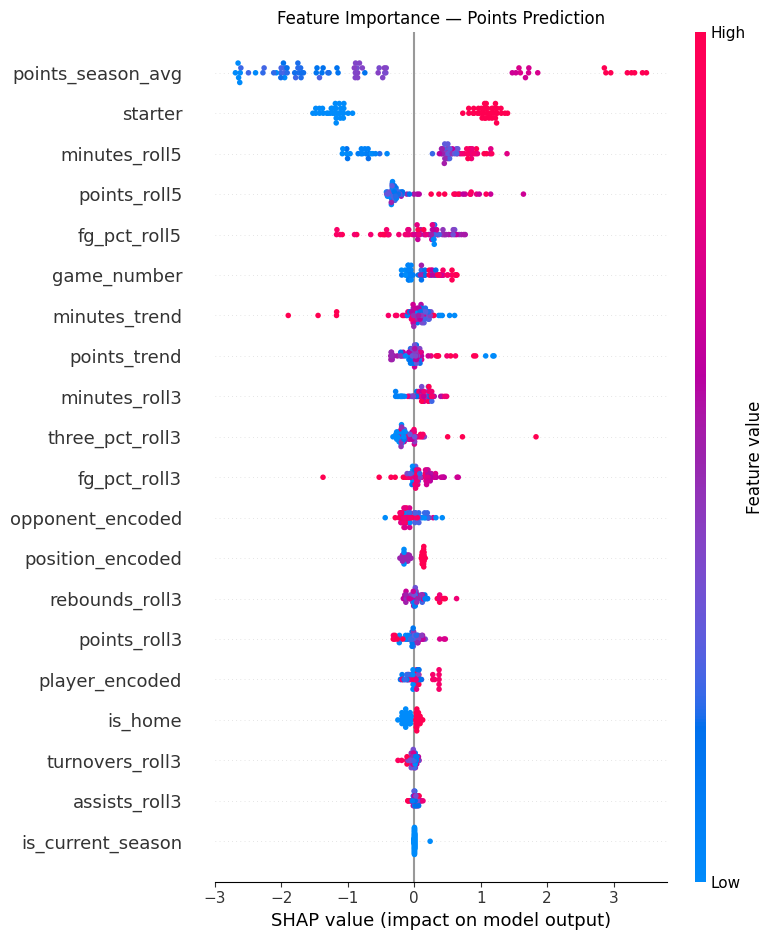

✅ SHAP plot saved


In [21]:
import shap

# Generate SHAP values on test set
explainer = shap.TreeExplainer(model_full)
shap_values = explainer.shap_values(X_test)

# Summary plot — shows which features matter most overall
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.title("Feature Importance — Points Prediction")
plt.tight_layout()
plt.savefig('/Users/sethgannon/Projects/big-blue-nation-ai-analyst/notebooks/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP plot saved")

In [22]:
# Current 2025-26 roster — only these players matter for predictions
current_roster = df_full[df_full['season'] == '2025-26']['player_name'].unique().tolist()
print(f"Current roster players: {len(current_roster)}")
print(sorted(current_roster))

# Filter full dataset to only current roster players
df_filtered = df_full[df_full['player_name'].isin(current_roster)].copy()

print(f"\nRecords before filter: {len(df_full)}")
print(f"Records after filter: {len(df_filtered)}")
print(f"\nBy season after filter:")
print(df_filtered['season'].value_counts())

print(f"\nPlayers removed (not on current roster):")
removed = [p for p in df_full['player_name'].unique() if p not in current_roster]
print(removed)

Current roster players: 14
['Andrija Jelavic', 'Brandon Garrison', 'Collin Chandler', 'Denzel Aberdeen', 'Jaland Lowe', 'Jasper Johnson', 'Jayden Quaintance', 'Kam Williams', 'Malachi Moreno', 'Mouhamed Dioubate', 'Otega Oweh', 'Trent Noah', 'Walker Horn', 'Zach Tow']

Records before filter: 669
Records after filter: 433

By season after filter:
season
2025-26    301
2024-25    132
Name: count, dtype: int64

Players removed (not on current roster):
['Amari Williams', 'Andrew Carr', 'Ansley Almonor', 'Grant Darbyshire', 'Jaxson Robinson', 'Kerr Kriisa', 'Koby Brea', 'Lamont Butler', 'Travis Perry']


In [25]:
# === ADD DAYS REST FEATURE ===
# Sort by player and date
df_full2 = df_filtered.copy()
df_full2['game_date'] = pd.to_datetime(df_full2['game_date'])
df_full2 = df_full2.sort_values(['player_name', 'game_date'])

# Calculate days since last game per player
df_full2['days_rest'] = df_full2.groupby('player_name')['game_date'].diff().dt.days
df_full2['days_rest'] = df_full2['days_rest'].fillna(7)  # first game = 7 days rest
df_full2['is_back_to_back'] = (df_full2['days_rest'] <= 1).astype(int)

print("Days rest distribution:")
print(df_full2['days_rest'].value_counts().sort_index().head(10))
print(f"\nBack to back games: {df_full2['is_back_to_back'].sum()}")

# === ADD OPPONENT DEFENSIVE STATS ===
opp_stats_df = pd.read_sql_query("""
    SELECT game_id, opponent, points as opp_points, 
           rebounds as opp_rebounds, assists as opp_assists,
           turnovers as opp_turnovers
    FROM opponent_game_stats
""", conn)

print(f"\nOpponent stats loaded: {len(opp_stats_df)} games")

# Calculate opponent defensive averages up to each game
# This tells us how good each opponent's defense has been
opp_defensive_avg = opp_stats_df.groupby('opponent').agg(
    opp_avg_points_allowed=('opp_points', 'mean'),
    opp_avg_rebounds=('opp_rebounds', 'mean'),
    opp_avg_turnovers_forced=('opp_turnovers', 'mean')
).round(2).reset_index()

print("\nOpponent defensive averages (Kentucky's scoring against them):")
print(opp_defensive_avg.sort_values('opp_avg_points_allowed').head(10))

Days rest distribution:
days_rest
1.0       4
2.0      32
3.0     115
4.0     127
5.0      47
6.0      37
7.0      27
8.0       4
9.0       1
10.0      4
Name: count, dtype: int64

Back to back games: 4

Opponent stats loaded: 66 games

Opponent defensive averages (Kentucky's scoring against them):
                        opponent  opp_avg_points_allowed  opp_avg_rebounds  \
20    Loyola Maryland Greyhounds                    46.0              33.0   
24             Nicholls Colonels                    51.0              30.0   
9      Eastern Illinois Panthers                    53.0              17.0   
32  Tennessee Tech Golden Eagles                    54.0              27.0   
4                    Brown Bears                    54.0              35.0   
36                  Troy Trojans                    57.0              38.0   
37            Valparaiso Beacons                    59.0              34.0   
16          Jackson State Tigers                    59.0              40.0  

In [26]:
# Merge days rest and opponent defensive stats into model dataset
df_full2 = df_full2.sort_values(['player_name', 'game_date']).reset_index(drop=True)

# Re-engineer all rolling features on filtered dataset
stats_to_roll = ['points', 'rebounds', 'assists', 'minutes',
                 'fg_pct', 'three_pct', 'turnovers', 'steals']

for stat in stats_to_roll:
    df_full2[f'{stat}_roll3'] = df_full2.groupby('player_name')[stat].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
    df_full2[f'{stat}_roll5'] = df_full2.groupby('player_name')[stat].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
    df_full2[f'{stat}_season_avg'] = df_full2.groupby('player_name')[stat].transform(
        lambda x: x.shift(1).expanding().mean()
    )

df_full2['is_home'] = (df_full2['home_away'] == 'home').astype(int)
df_full2['game_number'] = df_full2.groupby('player_name').cumcount() + 1
df_full2['minutes_trend'] = df_full2['minutes_roll3'] - df_full2['minutes_roll5']
df_full2['points_trend'] = df_full2['points_roll3'] - df_full2['points_roll5']
df_full2['is_current_season'] = (df_full2['season'] == '2025-26').astype(int)

# Season segment — early, mid, late
df_full2['season_segment'] = pd.cut(
    df_full2['game_number'],
    bins=[0, 10, 20, 100],
    labels=[1, 2, 3]
).astype(int)

# Merge opponent defensive averages
df_full2 = df_full2.merge(opp_defensive_avg, on='opponent', how='left')

# Merge win/loss
df_full2 = df_full2.merge(
    games_combined[['game_id', 'uk_win']],
    on='game_id',
    how='left'
)

print(f"Dataset ready: {len(df_full2)} records")
print(f"New features added: days_rest, is_back_to_back, opp_avg_points_allowed, season_segment")
print(f"\nNull check:")
print(df_full2[['days_rest', 'is_back_to_back', 'opp_avg_points_allowed', 'uk_win']].isnull().sum())

Dataset ready: 433 records
New features added: days_rest, is_back_to_back, opp_avg_points_allowed, season_segment

Null check:
days_rest                 0
is_back_to_back           0
opp_avg_points_allowed    0
uk_win                    0
dtype: int64


In [27]:
# Drop rows with NaN rolling averages
drop_cols = ['id', 'game_id', 'season', 'player_id', 'jersey', 'updated_at']
df_model2 = df_full2.drop(columns=[c for c in drop_cols if c in df_full2.columns])
df_model2 = df_model2.dropna(subset=['points_roll3'])

print(f"Modeling dataset: {len(df_model2)} records")

# Encode categoricals
le_player2 = LabelEncoder()
le_position2 = LabelEncoder()
le_opponent2 = LabelEncoder()

df_model2 = df_model2.copy()
df_model2['player_encoded'] = le_player2.fit_transform(df_model2['player_name'])
df_model2['position_encoded'] = le_position2.fit_transform(df_model2['position'].fillna('G'))
df_model2['opponent_encoded'] = le_opponent2.fit_transform(df_model2['opponent'])

# Updated feature set — includes new features
feature_cols2 = [
    # Rolling averages
    'points_roll3', 'points_roll5', 'points_season_avg',
    'rebounds_roll3', 'assists_roll3', 'minutes_roll3', 'minutes_roll5',
    'fg_pct_roll3', 'fg_pct_roll5', 'three_pct_roll3', 'turnovers_roll3',
    # Trends
    'points_trend', 'minutes_trend',
    # Game context
    'is_home', 'game_number', 'starter', 'is_current_season',
    'season_segment',
    # New features
    'days_rest', 'is_back_to_back',
    'opp_avg_points_allowed', 'opp_avg_rebounds', 'opp_avg_turnovers_forced',
    # Encoded categoricals
    'player_encoded', 'position_encoded', 'opponent_encoded'
]

X2 = df_model2[feature_cols2]
y2 = df_model2['points']

# Chronological train/test split
test_mask2 = (df_model2['game_date'] >= '2026-02-01') & (df_model2['is_current_season'] == 1)
train_mask2 = ~test_mask2

X_train2, X_test2 = X2[train_mask2], X2[test_mask2]
y_train2, y_test2 = y2[train_mask2], y2[test_mask2]

print(f"Training: {len(X_train2)} | Test: {len(X_test2)}")

# Train model
model_v3 = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)

model_v3.fit(X_train2, y_train2)

# Evaluate
preds_train2 = model_v3.predict(X_train2)
preds_test2 = model_v3.predict(X_test2)

mae_train2 = mean_absolute_error(y_train2, preds_train2)
mae_test2 = mean_absolute_error(y_test2, preds_test2)
baseline_mae2 = mean_absolute_error(y_test2, [y_train2.mean()] * len(y_test2))

print(f"\n=== FULL MODEL COMPARISON ===")
print(f"{'Model':<35} {'Train MAE':<12} {'Test MAE':<12} {'vs Baseline'}")
print(f"{'-'*35} {'-'*12} {'-'*12} {'-'*12}")
print(f"{'Baseline':<35} {'N/A':<12} {baseline_mae2:<12.2f} {'—'}")
print(f"{'30 games only':<35} {'1.00':<12} {'4.92':<12} {'+0.98 pts'}")
print(f"{'66 games, all players':<35} {'3.09':<12} {'4.16':<12} {'+1.71 pts'}")
print(f"{'66 games, current roster':<35} {mae_train2:<12.2f} {mae_test2:<12.2f} {baseline_mae2 - mae_test2:.2f} pts")

Modeling dataset: 419 records
Training: 347 | Test: 72

=== FULL MODEL COMPARISON ===
Model                               Train MAE    Test MAE     vs Baseline
----------------------------------- ------------ ------------ ------------
Baseline                            N/A          5.85         —
30 games only                       1.00         4.92         +0.98 pts
66 games, all players               3.09         4.16         +1.71 pts
66 games, current roster            2.47         4.07         1.77 pts


In [28]:
# Drop rows with NaN rolling averages
drop_cols = ['id', 'game_id', 'season', 'player_id', 'jersey', 'updated_at']
df_model2 = df_full2.drop(columns=[c for c in drop_cols if c in df_full2.columns])
df_model2 = df_model2.dropna(subset=['points_roll3'])

print(f"Modeling dataset: {len(df_model2)} records")

# Encode categoricals
le_player2 = LabelEncoder()
le_position2 = LabelEncoder()
le_opponent2 = LabelEncoder()

df_model2 = df_model2.copy()
df_model2['player_encoded'] = le_player2.fit_transform(df_model2['player_name'])
df_model2['position_encoded'] = le_position2.fit_transform(df_model2['position'].fillna('G'))
df_model2['opponent_encoded'] = le_opponent2.fit_transform(df_model2['opponent'])

# Updated feature set — includes new features
feature_cols2 = [
    # Rolling averages
    'points_roll3', 'points_roll5', 'points_season_avg',
    'rebounds_roll3', 'assists_roll3', 'minutes_roll3', 'minutes_roll5',
    'fg_pct_roll3', 'fg_pct_roll5', 'three_pct_roll3', 'turnovers_roll3',
    # Trends
    'points_trend', 'minutes_trend',
    # Game context
    'is_home', 'game_number', 'starter', 'is_current_season',
    'season_segment',
    # New features
    'days_rest', 'is_back_to_back',
    'opp_avg_points_allowed', 'opp_avg_rebounds', 'opp_avg_turnovers_forced',
    # Encoded categoricals
    'player_encoded', 'position_encoded', 'opponent_encoded'
]

X2 = df_model2[feature_cols2]
y2 = df_model2['points']

# Chronological train/test split
test_mask2 = (df_model2['game_date'] >= '2026-02-01') & (df_model2['is_current_season'] == 1)
train_mask2 = ~test_mask2

X_train2, X_test2 = X2[train_mask2], X2[test_mask2]
y_train2, y_test2 = y2[train_mask2], y2[test_mask2]

print(f"Training: {len(X_train2)} | Test: {len(X_test2)}")

# Train model
model_v3 = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)

model_v3.fit(X_train2, y_train2)

# Evaluate
preds_train2 = model_v3.predict(X_train2)
preds_test2 = model_v3.predict(X_test2)

mae_train2 = mean_absolute_error(y_train2, preds_train2)
mae_test2 = mean_absolute_error(y_test2, preds_test2)
baseline_mae2 = mean_absolute_error(y_test2, [y_train2.mean()] * len(y_test2))

print(f"\n=== FULL MODEL COMPARISON ===")
print(f"{'Model':<35} {'Train MAE':<12} {'Test MAE':<12} {'vs Baseline'}")
print(f"{'-'*35} {'-'*12} {'-'*12} {'-'*12}")
print(f"{'Baseline':<35} {'N/A':<12} {baseline_mae2:<12.2f} {'—'}")
print(f"{'30 games only':<35} {'1.00':<12} {'4.92':<12} {'+0.98 pts'}")
print(f"{'66 games, all players':<35} {'3.09':<12} {'4.16':<12} {'+1.71 pts'}")
print(f"{'66 games, current roster':<35} {mae_train2:<12.2f} {mae_test2:<12.2f} {baseline_mae2 - mae_test2:.2f} pts")

Modeling dataset: 419 records
Training: 347 | Test: 72

=== FULL MODEL COMPARISON ===
Model                               Train MAE    Test MAE     vs Baseline
----------------------------------- ------------ ------------ ------------
Baseline                            N/A          5.85         —
30 games only                       1.00         4.92         +0.98 pts
66 games, all players               3.09         4.16         +1.71 pts
66 games, current roster            2.47         4.07         1.77 pts


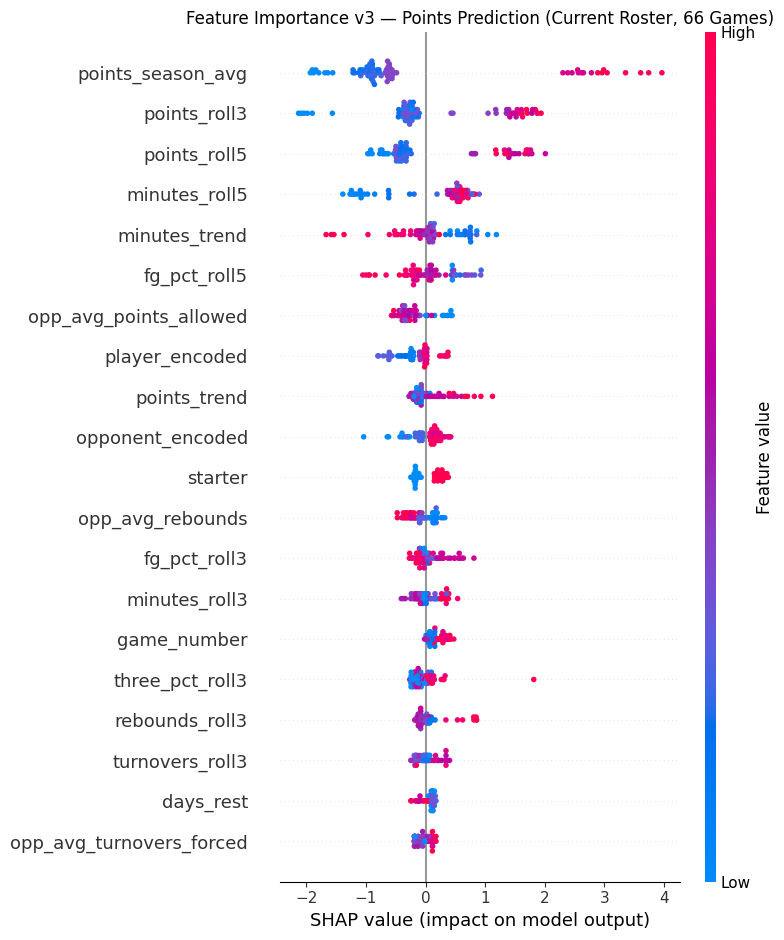

✅ SHAP plot saved


In [29]:
# Updated SHAP plot with improved model
explainer2 = shap.TreeExplainer(model_v3)
shap_values2 = explainer2.shap_values(X_test2)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values2, X_test2, feature_names=feature_cols2, show=False)
plt.title("Feature Importance v3 — Points Prediction (Current Roster, 66 Games)")
plt.tight_layout()
plt.savefig('/Users/sethgannon/Projects/big-blue-nation-ai-analyst/notebooks/shap_summary_v3.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP plot saved")

In [31]:
# === NEXT GAME PREDICTION — FLORIDA vs KENTUCKY ===
# Build prediction for each current player for the Florida game

def predict_next_game(player_name, opponent, is_home, days_rest_val=3):
    """Generate point prediction with confidence interval for a player"""
    
    # Get player's most recent stats
    player_data = df_model2[df_model2['player_name'] == player_name].sort_values('game_date')
    
    if len(player_data) == 0:
        return None
    
    last_game = player_data.iloc[-1]
    
    # Get opponent defensive stats
    opp_stats = opp_defensive_avg[opp_defensive_avg['opponent'] == opponent]
    if len(opp_stats) == 0:
        # Use league average if opponent not in our data
        opp_pts = opp_defensive_avg['opp_avg_points_allowed'].mean()
        opp_reb = opp_defensive_avg['opp_avg_rebounds'].mean()
        opp_to = opp_defensive_avg['opp_avg_turnovers_forced'].mean()
    else:
        opp_pts = opp_stats['opp_avg_points_allowed'].values[0]
        opp_reb = opp_stats['opp_avg_rebounds'].values[0]
        opp_to = opp_stats['opp_avg_turnovers_forced'].values[0]
    
    # Build feature vector
    features = {
        'points_roll3': last_game['points_roll3'],
        'points_roll5': last_game['points_roll5'],
        'points_season_avg': last_game['points_season_avg'],
        'rebounds_roll3': last_game['rebounds_roll3'],
        'assists_roll3': last_game['assists_roll3'],
        'minutes_roll3': last_game['minutes_roll3'],
        'minutes_roll5': last_game['minutes_roll5'],
        'fg_pct_roll3': last_game['fg_pct_roll3'],
        'fg_pct_roll5': last_game['fg_pct_roll5'],
        'three_pct_roll3': last_game['three_pct_roll3'],
        'turnovers_roll3': last_game['turnovers_roll3'],
        'points_trend': last_game['points_trend'],
        'minutes_trend': last_game['minutes_trend'],
        'is_home': int(is_home),
        'game_number': last_game['game_number'] + 1,
        'starter': last_game['starter'],
        'is_current_season': 1,
        'season_segment': 3,
        'days_rest': days_rest_val,
        'is_back_to_back': 1 if days_rest_val <= 1 else 0,
        'opp_avg_points_allowed': opp_pts,
        'opp_avg_rebounds': opp_reb,
        'opp_avg_turnovers_forced': opp_to,
        'player_encoded': le_player2.transform([player_name])[0] if player_name in le_player2.classes_ else 0,
        'position_encoded': le_position2.transform([last_game['position']])[0] if last_game['position'] in le_position2.classes_ else 0,
        'opponent_encoded': le_opponent2.transform([opponent])[0] if opponent in le_opponent2.classes_ else 0,
    }
    
    X_pred = pd.DataFrame([features])[feature_cols2]
    point_pred = model_v3.predict(X_pred)[0]
    
    # Confidence interval via bootstrapping
    bootstrap_preds = []
    np.random.seed(42)
    for _ in range(100):
        noise = np.random.normal(0, mae_test2, 1)[0]
        bootstrap_preds.append(point_pred + noise)
    
    lower = max(0, np.percentile(bootstrap_preds, 10))
    upper = np.percentile(bootstrap_preds, 90)
    
    return {
        'player': player_name,
        'predicted_points': round(point_pred, 1),
        'lower': round(lower, 1),
        'upper': round(upper, 1),
        'season_avg': round(last_game['points_season_avg'], 1),
        'roll3_avg': round(last_game['points_roll3'], 1),
        'starter': bool(last_game['starter']),
        'minutes_proj': round(last_game['minutes_roll5'], 1),
    }

# Run predictions for all current roster players vs Florida
print("🏀 KENTUCKY vs FLORIDA — PLAYER PROJECTIONS")
print("=" * 65)
print(f"  Home | Saturday March 7 @ 4:00 PM ET | ESPN | Rupp Arena")
print(f"  ⚠️  OUT: Jayden Quaintance, Jaland Lowe, Kam Williams (injured)")
print(f"  {'Player':<25} {'Proj':<8} {'Range':<15} {'Season':<8} {'L3 Avg'}")
print(f"  {'-'*25} {'-'*8} {'-'*15} {'-'*8} {'-'*8}")

starters = []
bench = []

expected_starters = [
    'Otega Oweh', 'Denzel Aberdeen', 'Collin Chandler',
    'Malachi Moreno', 'Andrija Jelavic'
]

injured_players = ['Jayden Quaintance', 'Jaland Lowe', 'Kam Williams']

for player in sorted(current_roster):
    if player in injured_players:
        continue
    result = predict_next_game(
        player_name=player,
        opponent='Florida Gators',
        is_home=True,
        days_rest_val=3
    )
    if result:
        result['starter'] = player in expected_starters
        if result['starter']:
            starters.append(result)
        else:
            bench.append(result)

# Sort by projected points
starters = sorted(starters, key=lambda x: x['predicted_points'], reverse=True)
bench = sorted(bench, key=lambda x: x['predicted_points'], reverse=True)

print("\n  STARTERS:")
for r in starters:
    range_str = f"{r['lower']}-{r['upper']}"
    print(f"  {r['player']:<25} {r['predicted_points']:<8.1f} {range_str:<15} {r['season_avg']:<8.1f} {r['roll3_avg']:.1f}")

print("\n  BENCH:")
for r in bench:
    range_str = f"{r['lower']}-{r['upper']}"
    print(f"  {r['player']:<25} {r['predicted_points']:<8.1f} {range_str:<15} {r['season_avg']:<8.1f} {r['roll3_avg']:.1f}")

total_proj = sum(r['predicted_points'] for r in starters + bench)
print(f"\n  Projected Team Total: {total_proj:.1f} points")

🏀 KENTUCKY vs FLORIDA — PLAYER PROJECTIONS
  Player                    Proj     Range           Season   L3 Avg
  ------------------------- -------- --------------- -------- --------

  STARTERS:
  Otega Oweh                16.700000762939453 11.3-20.8       16.9     20.0
  Denzel Aberdeen           14.199999809265137 8.8-18.3        13.0     16.3
  Collin Chandler           10.0     4.6-14.1        6.5      14.3
  Malachi Moreno            7.5      2.1-11.6        8.4      8.7
  Kam Williams              6.300000190734863 0.9-10.4        6.8      7.0
  Jaland Lowe               5.800000190734863 0.4-9.9         9.0      14.3
  Andrija Jelavic           5.199999809265137 0-9.3           5.8      7.3
  Jayden Quaintance         4.800000190734863 0-8.9           6.3      6.3

  BENCH:
  Mouhamed Dioubate         7.0      1.6-11.1        8.0      8.0
  Brandon Garrison          5.0      0-9.1           5.1      3.3
  Jasper Johnson            3.299999952316284 0-7.4           5.6      1.0